---

# 📏 **Feature Scaling in Neural Networks**  
*A key to faster learning, better convergence & stable gradients*

---

## ✅ **What is Feature Scaling?**

📌 **Feature Scaling** refers to **normalizing or standardizing input features** so that they are on a similar scale — typically **between 0 and 1**, or with **zero mean and unit variance**.

> 💡 Neural networks are sensitive to the scale of input data, especially when using **gradient-based optimizers**.

---

## 🧠 **Why Feature Scaling is Important in Neural Networks**

### Without feature scaling:
- Features with large values (e.g., salary in ₹ or $) dominate features with smaller values (e.g., age, height).
- Leads to:
  - ❌ **Slow convergence**
  - ❌ **Unstable gradients**
  - ❌ **Poor model performance**

---

## ⚙️ **How It Affects Neural Network Training**

| Step                     | Impact Without Scaling           | Impact With Scaling            |
|--------------------------|----------------------------------|--------------------------------|
| 🔁 Gradient Descent       | Large steps or tiny steps        | Consistent, efficient steps    |
| ⚖️ Weight Updates         | Skewed by large input magnitudes | Balanced updates across layers |
| 🧮 Activation Functions    | Sigmoid/Tanh may **saturate**    | Stay in sensitive regions      |
| ⏱️ Training Speed         | Very slow                       | Much faster                    |

---

## 🔢 **Common Feature Scaling Techniques**

### 🔹 1. **Min-Max Scaling (Normalization)**  
Scales values to range **[0, 1]**:
$
x_{\text{scaled}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}
$

✅ Ideal for input features going into **sigmoid** or **ReLU** activations  
✅ Preserves **original distribution**

---

### 🔹 2. **Standardization (Z-score Normalization)**  
Centers data around 0 with unit variance:
$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$

✅ Best when data is **normally distributed**  
✅ Preferred with **Tanh**, **Softmax**, or **linear** activations

---

### 🔹 3. **Robust Scaling**  
Scales using **median** and **IQR**:
$
x_{\text{scaled}} = \frac{x - \text{median}}{\text{IQR}}
$

✅ Useful when data has **outliers**

---

## 💻 **Example: Feature Scaling in Python with `sklearn`**

```python
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# Sample data
X = np.array([[200, 1.8], [150, 1.6], [180, 1.7]])

# Standardization
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

# Normalization
scaler_minmax = MinMaxScaler()
X_norm = scaler_minmax.fit_transform(X)

print("Standardized:\n", X_std)
print("Normalized:\n", X_norm)
```

---

## 🚀 **Feature Scaling in Neural Network Pipelines**

### 🧱 Typical Steps:
1. Scale inputs using `StandardScaler` or `MinMaxScaler`
2. Train neural network (MLP, CNN, etc.)
3. (Optional) Apply inverse transform on outputs (e.g., in regression)

✅ Always scale **training**, **validation**, and **test** data using the same scaler (`fit` on train, `transform` on others)

---

## 🧠 **Best Practices**

| Scenario                          | Recommended Scaling       |
|----------------------------------|---------------------------|
| ✅ General Deep Learning          | StandardScaler             |
| ✅ Image Pixel Inputs (0–255)     | MinMaxScaler (0–1)         |
| ✅ Input to Sigmoid / ReLU        | MinMaxScaler (0–1)         |
| ✅ Data with outliers             | RobustScaler               |
| ✅ BatchNorm in model             | Still scale inputs first! |

---

## 🔍 **What Happens If You Don’t Scale?**

❌ Slower training  
❌ Models may **not converge**  
❌ Poor generalization  
❌ Gradient Descent may get stuck  
❌ Vanishing gradients (especially with sigmoid/tanh)

---

## 🧪 Summary

| Feature                      | Scaling Benefit |
|------------------------------|------------------|
| 🏃 Faster Training            | ✔️ Faster convergence |
| 🎯 Better Accuracy            | ✔️ Balanced learning |
| 📉 Prevent Vanishing Gradients| ✔️ Stabilizes activations |
| ⚙️ Optimizer Performance      | ✔️ Consistent gradients |

---

## 🧠 TL;DR

> "**Feature scaling is not optional — it’s essential for stable and fast learning in neural networks.**"

---


#**Further Practice**

In [18]:
import numpy as np
import pandas as pd

In [19]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [20]:
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

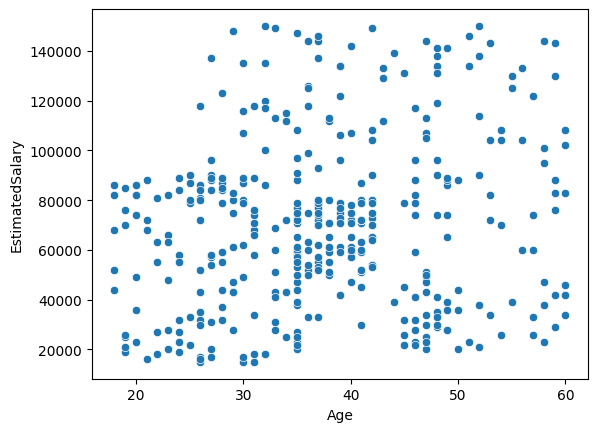

In [22]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1]) # Pass x and y as keyword arguments.
plt.show()

In [23]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [25]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

import warnings
warnings.filterwarnings('ignore')

In [26]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [29]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5205 - loss: 363.4026 - val_accuracy: 0.4000 - val_loss: 191.2380
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4662 - loss: 152.2088 - val_accuracy: 0.4000 - val_loss: 55.4336
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5252 - loss: 35.2363 - val_accuracy: 0.4000 - val_loss: 65.0986
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 72.6653 - val_accuracy: 0.4000 - val_loss: 131.3635
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5638 - loss: 100.0170 - val_accuracy: 0.4000 - val_loss: 192.1209
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4097 - loss: 171.9970 - val_accuracy: 0.4000 - val_loss: 139.6598
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4449 - loss: 146.7733 - val_accuracy: 0.4000 - val_loss: 14.1971
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4377 - loss: 22

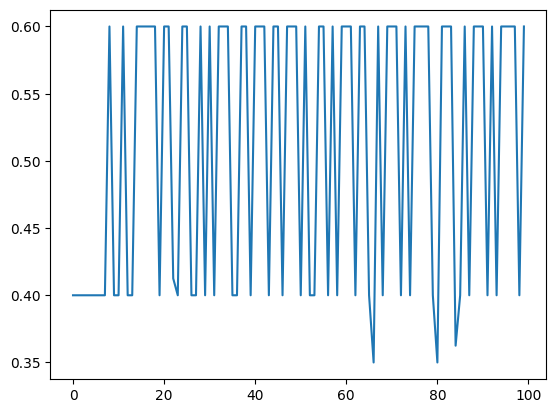

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])
plt.show()

# **Applying scaling**

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled

array([[ 0.88928823, -0.65924556],
       [-0.17254846,  0.87392651],
       [-1.04132394, -0.36440478],
       [ 0.98581884,  0.6085698 ],
       [-0.94479333,  0.57908572],
       [ 0.40663519,  0.01888824],
       [ 0.98581884,  2.11225779],
       [ 0.31010458, -0.30543662],
       [ 1.7580637 , -0.27595254],
       [-0.17254846,  2.20071003],
       [ 1.7580637 ,  1.0213469 ],
       [-1.33091576, -1.48479975],
       [ 2.04765553,  0.54960165],
       [ 1.27541066,  1.90586924],
       [-1.13785454,  0.31372902],
       [-0.36560968, -0.77718187],
       [-1.71703819,  0.49063349],
       [-0.5586709 , -1.51428383],
       [ 0.31010458, -0.71821372],
       [ 0.02051275, -0.57079333],
       [ 0.02051275,  0.04837232],
       [-0.07601785, -0.51182517],
       [-0.6552015 , -1.51428383],
       [ 0.02051275,  0.31372902],
       [ 0.31010458,  0.07785639],
       [-0.46214029, -1.13099081],
       [-0.75173211, -1.54376791],
       [-0.26907907, -0.65924556],
       [-1.13785454,

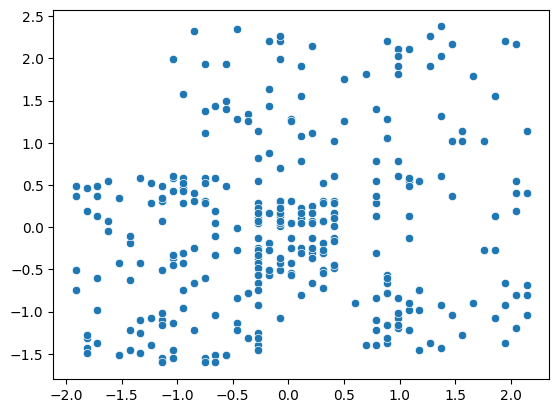

In [34]:
sns.scatterplot(x=X_train_scaled[:,0], y=X_train_scaled[:,1]) # Pass x and y as keyword arguments.
plt.show()

In [35]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.6811 - loss: 0.6095 - val_accuracy: 0.6750 - val_loss: 0.5797
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7115 - loss: 0.5780 - val_accuracy: 0.7250 - val_loss: 0.5311
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7490 - loss: 0.5182 - val_accuracy: 0.7625 - val_loss: 0.4897
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7896 - loss: 0.4908 - val_accuracy: 0.7750 - val_loss: 0.4555
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8349 - loss: 0.4513 - val_accuracy: 0.7750 - val_loss: 0.4275
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8616 - loss: 0.4251 - val_accuracy: 0.7750 - val_loss: 0.4055
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8246 - loss: 0.4225 - val_accuracy: 0.8000 - val_loss: 0.3870
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8681 - loss: 0.3900 - val_accuracy: 0.

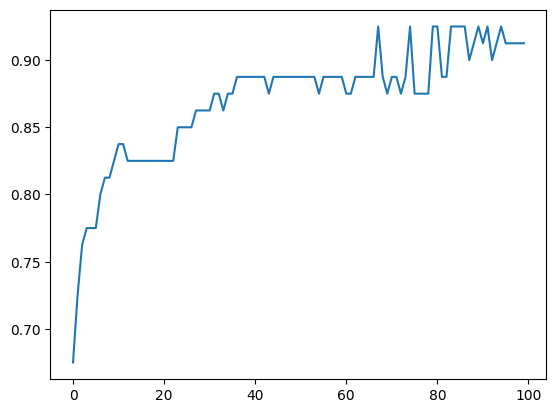

In [36]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])
plt.show()

---